In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from pathlib import Path

from hcc_multimodal.baselines.config import MODELS_LR, MODELS_RF
from hcc_multimodal.baselines.data import add_rfs_columns
from hcc_multimodal.baselines.transforms import DataType
from hcc_multimodal.baselines.evaluation import (
    run_cv_experiment,
    plot_cv_results,
    apply_selector_before_cv,
)
from sklearn.feature_selection import SelectKBest, f_classif

In [3]:
RANDOM_STATE = 42
SELECT_K = 100
RFS_YEARS = [1, 2]
CV_N_FOLDS = 3

SELECTOR_BEFORE_CV: bool = True
OUTPUT_DIR_NAME: str = "kbest_f100_before_cv"

# Read data

In [4]:
ROOT = Path().resolve().parents[1]

clinical_data = pd.read_csv(
    ROOT
    / "data"
    / "Clinical"
    / "2025_Nov_18_ICL_Resection_Clinical_Outcome_soramic_format.csv"
).dropna(how="all")

arterial_data = pd.read_csv(
    ROOT / "data" / "Radiomics" / "arterial_radiomics.csv"
).dropna(how="all")

In [5]:
arterial_data["SID"] = (
    arterial_data["Scan name"].str.replace(r"\.nii\.gz$", "", regex=True).astype(int)
)
arterial_data = arterial_data.drop(
    columns=["Scan name", "VOI name", "Scan path", "VOI path"]
)

feature_cols = [c for c in arterial_data.columns if c != "SID"]
print(f"Arterial radiomic features: {len(feature_cols)}")
print(f"Patients: {len(arterial_data)}")
arterial_data.head()

Arterial radiomic features: 4132
Patients: 60


/var/folders/9s/lbf5r70j6_1_c29ygw008t_m0000gn/T/ipykernel_79556/4085038068.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  arterial_data["SID"] = (


,N voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,SNS_max3d,FOS_CV,...,GrayLevelDependenceNonUniformity3D,NormalisedGrayLevelDependenceNonUniformity3D,DependenceCountNonUniformity3D,NormalisedDependenceCountNonUniformity3D,DependenceCountPercentage3D,GrayLevelDependenceVariance3D,DependenceCountVariance3D,DependenceCountEntropy3D,DependenceCountEnergy3D,SID
0,97488,97488,21902,0.224664,0.467700,2.138121,70.261978,0.102307,85,-2.263285e+15,...,9446.080896,0.032748,41052.828722,0.142325,1,82.354277,5.061722,8.206667,0.004560,10
1,30229,30229,9800,0.324192,0.478859,2.088299,37.241868,0.109805,59,-2.404568e+15,...,2544.956414,0.028068,12415.469257,0.136929,1,97.769370,5.419350,8.388275,0.003901,113
2,12429,12429,5544,0.446054,0.468042,2.136559,22.386134,0.102531,45,-3.271783e+15,...,1089.047634,0.029342,6232.340931,0.167915,1,92.694520,3.618023,8.070940,0.004905,114
3,11164,11164,6354,0.569151,0.380175,2.630368,18.360313,0.054948,54,1.170157e+15,...,969.123382,0.029037,5548.032239,0.166228,1,94.108788,3.688515,8.095993,0.004786,115
4,6745,6745,3408,0.505263,0.506570,1.974062,16.803792,0.129992,37,-1.998977e+15,...,600.894784,0.029766,3215.891861,0.159305,1,95.723621,3.873044,8.089906,0.004742,121


# RFS column

In [6]:
clinical_data = add_rfs_columns(clinical_data)
clinical_data[["RFS_central", "RFS_central_event", "rfs_1year", "rfs_2year"]].head(10)

,RFS_central,RFS_central_event,rfs_1year,rfs_2year
0,31.791781,0.0,0.0,0.0
1,30.279452,1.0,0.0,0.0
2,40.865753,1.0,0.0,0.0
3,14.301370,1.0,0.0,1.0
4,24.756164,1.0,0.0,0.0
5,9.600000,1.0,1.0,1.0
6,8.054795,1.0,1.0,1.0
7,6.936986,1.0,1.0,1.0
8,49.643836,1.0,0.0,0.0
9,11.441096,1.0,1.0,1.0


In [7]:
clinical_data[["RFS_central", "RFS_central_event", "rfs_1year", "rfs_2year"]].tail(10)

,RFS_central,RFS_central_event,rfs_1year,rfs_2year
59,52.734247,0.0,0.0,0.0
60,63.813699,1.0,0.0,0.0
61,75.879452,0.0,0.0,0.0
62,2.367123,0.0,NaN,NaN
63,7.791781,1.0,1.0,1.0
64,5.983562,1.0,1.0,1.0
65,5.786301,1.0,1.0,1.0
66,132.526027,1.0,0.0,0.0
67,27.320548,1.0,0.0,0.0
68,97.347945,0.0,0.0,0.0


In [8]:
print(clinical_data["rfs_1year"].value_counts(dropna=False))
print(clinical_data["rfs_2year"].value_counts(dropna=False))

rfs_1year
0.0    43
1.0    21
NaN     5
Name: count, dtype: int64
rfs_2year
0.0    33
1.0    29
NaN     7
Name: count, dtype: int64


In [9]:
arterial_rfs = arterial_data.merge(
    clinical_data[["SID", "rfs_1year", "rfs_2year"]], on="SID"
)
arterial_rfs = arterial_rfs.set_index("SID")
print(f"Matched patients: {len(arterial_rfs)}")
arterial_rfs.head()

Matched patients: 60


,N voxels,SNS_vol,SNS_area,SNS_s2v,SNS_sph,SNS_sph_dis,SNS_com_1,SNS_com_2,SNS_max3d,FOS_CV,...,NormalisedGrayLevelDependenceNonUniformity3D,DependenceCountNonUniformity3D,NormalisedDependenceCountNonUniformity3D,DependenceCountPercentage3D,GrayLevelDependenceVariance3D,DependenceCountVariance3D,DependenceCountEntropy3D,DependenceCountEnergy3D,rfs_1year,rfs_2year
SID,,,,,,,,,,,,,,,,,,,,,
10,97488,97488,21902,0.224664,0.467700,2.138121,70.261978,0.102307,85,-2.263285e+15,...,0.032748,41052.828722,0.142325,1,82.354277,5.061722,8.206667,0.004560,0.0,0.0
113,30229,30229,9800,0.324192,0.478859,2.088299,37.241868,0.109805,59,-2.404568e+15,...,0.028068,12415.469257,0.136929,1,97.769370,5.419350,8.388275,0.003901,1.0,1.0
114,12429,12429,5544,0.446054,0.468042,2.136559,22.386134,0.102531,45,-3.271783e+15,...,0.029342,6232.340931,0.167915,1,92.694520,3.618023,8.070940,0.004905,0.0,1.0
115,11164,11164,6354,0.569151,0.380175,2.630368,18.360313,0.054948,54,1.170157e+15,...,0.029037,5548.032239,0.166228,1,94.108788,3.688515,8.095993,0.004786,1.0,1.0
121,6745,6745,3408,0.505263,0.506570,1.974062,16.803792,0.129992,37,-1.998977e+15,...,0.029766,3215.891861,0.159305,1,95.723621,3.873044,8.089906,0.004742,0.0,NaN


# CV experiments

In [10]:
OUTPUT_DIR = ROOT / "reports" / "0504" / OUTPUT_DIR_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("OUTPUT_DIR:", OUTPUT_DIR)

OUTPUT_DIR: /Users/amo/programData/hcc-multimodal/reports/0504/kbest_f100_before_cv


[RFS 1 year - Arterial Radiomics] selector applied before CV: 100 features
[RFS 1 year - Arterial Radiomics]  n=56  positives=19  features=100


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  58  491  924 1357 1790 2223 2656 3088 3089 3522 3923 3972 4127] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


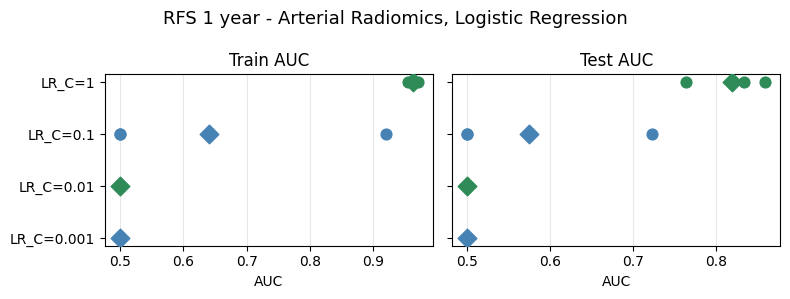

[RFS 1 year - Arterial Radiomics]  n=56  positives=19  features=100


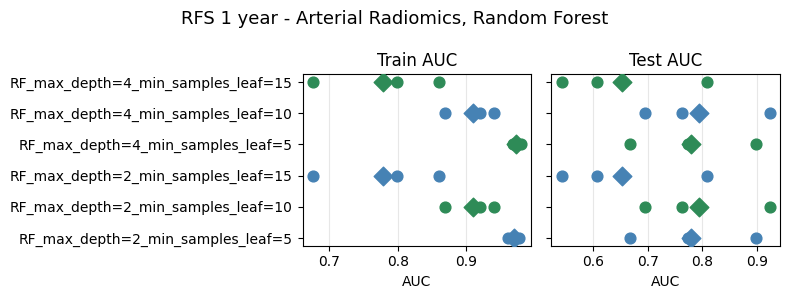

[RFS 2 year - Arterial Radiomics] selector applied before CV: 100 features
[RFS 2 year - Arterial Radiomics]  n=54  positives=26  features=100


/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  58  491  924 1357 1790 2223 2656 3088 3089 3522 3923 3972 4127] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/amo/programData/hcc-multimodal/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


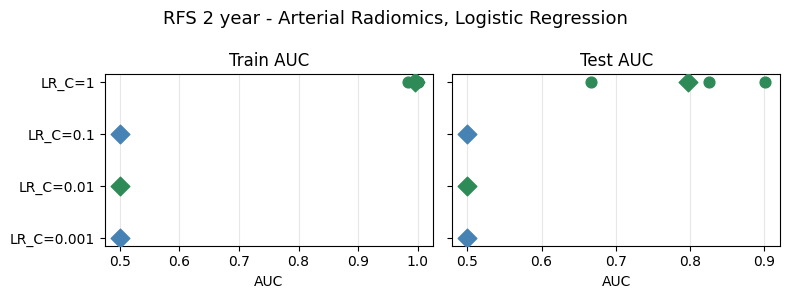

[RFS 2 year - Arterial Radiomics]  n=54  positives=26  features=100


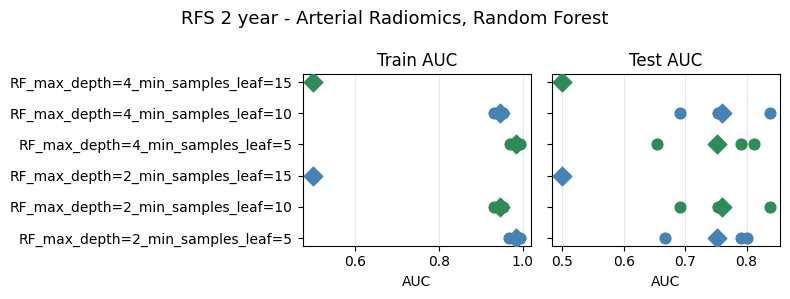

,experiment,model,AUC mean,AUC std,Accuracy mean,Accuracy std
0,RFS 1 year - Arterial Radiomics,LR_C=0.001,0.500,0.000,0.661,0.022
1,RFS 1 year - Arterial Radiomics,LR_C=0.01,0.500,0.000,0.661,0.022
2,RFS 1 year - Arterial Radiomics,LR_C=0.1,0.574,0.105,0.624,0.053
3,RFS 1 year - Arterial Radiomics,LR_C=1,0.819,0.040,0.694,0.100
4,RFS 1 year - Arterial Radiomics,RF_max_depth=2_min_samples_leaf=5,0.779,0.094,0.677,0.080
5,RFS 1 year - Arterial Radiomics,RF_max_depth=2_min_samples_leaf=10,0.793,0.096,0.695,0.104
6,RFS 1 year - Arterial Radiomics,RF_max_depth=2_min_samples_leaf=15,0.652,0.113,0.661,0.022
7,RFS 1 year - Arterial Radiomics,RF_max_depth=4_min_samples_leaf=5,0.779,0.094,0.677,0.080
8,RFS 1 year - Arterial Radiomics,RF_max_depth=4_min_samples_leaf=10,0.793,0.096,0.695,0.104
9,RFS 1 year - Arterial Radiomics,RF_max_depth=4_min_samples_leaf=15,0.652,0.113,0.661,0.022


In [11]:
X = arterial_rfs.drop(columns=["rfs_1year", "rfs_2year"])
x_columns = {col: DataType.CONTINUOUS for col in X}

selector = SelectKBest(f_classif, k=SELECT_K)

all_records = []
all_fold_records = []

for RFS_YEAR in RFS_YEARS:
    y = arterial_rfs[f"rfs_{RFS_YEAR}year"]
    EXPERIMENT_LABEL = f"RFS {RFS_YEAR} year - Arterial Radiomics"

    if SELECTOR_BEFORE_CV:
        X_cv, y_cv, x_columns_cv, cv_kwargs = apply_selector_before_cv(
            X, y, x_columns, selector,
            selector_first=False,
            label=EXPERIMENT_LABEL,
            save_path=OUTPUT_DIR / f"rfs_{RFS_YEAR}y_preselected_features.csv",
        )
    else:
        X_cv, y_cv, x_columns_cv = X, y, x_columns
        cv_kwargs = dict(feature_selector=selector, selector_first=False)

    records_lr, fold_records_lr = run_cv_experiment(
        X_cv, y_cv, x_columns_cv, EXPERIMENT_LABEL,
        models=MODELS_LR, n_splits=CV_N_FOLDS,
        **cv_kwargs,
    )
    plot_cv_results(
        fold_records_lr,
        title=f"{EXPERIMENT_LABEL}, Logistic Regression",
        save_path=OUTPUT_DIR / f"rfs_{RFS_YEAR}y_lr.png",
    )

    records_rf, fold_records_rf = run_cv_experiment(
        X_cv, y_cv, x_columns_cv, EXPERIMENT_LABEL,
        models=MODELS_RF, n_splits=CV_N_FOLDS,
        **cv_kwargs,
    )
    plot_cv_results(
        fold_records_rf,
        title=f"{EXPERIMENT_LABEL}, Random Forest",
        save_path=OUTPUT_DIR / f"rfs_{RFS_YEAR}y_rf.png",
    )

    all_records.extend([records_lr, records_rf])
    all_fold_records.append((RFS_YEAR, fold_records_lr))

summary = pd.concat(all_records, ignore_index=True)
summary.to_csv(OUTPUT_DIR / "summary.csv", index=False)
display(summary)

In [12]:
# Save non-zero L1 LR features per RFS year
for RFS_YEAR, fold_records_lr in all_fold_records:
    rows = []
    for _, row in fold_records_lr.iterrows():
        if row["lr_nonzero_features"] is not None and len(row["lr_nonzero_features"]) > 0:
            df = row["lr_nonzero_features"].copy()
            df["model"] = row["model"]
            df["fold"] = row["fold"]
            rows.append(df)

    if not rows:
        print(f"RFS {RFS_YEAR}y: no non-zero features found")
        continue

    combined = pd.concat(rows, ignore_index=True)
    combined.to_csv(OUTPUT_DIR / f"nonzero_features_rfs_{RFS_YEAR}y_all_folds.csv", index=False)

    union_features = sorted(combined["feature"].unique())
    txt_path = OUTPUT_DIR / f"nonzero_features_rfs_{RFS_YEAR}y_union.txt"
    with open(txt_path, "w") as f:
        f.write(f"# Non-zero L1-regularised LR features for RFS {RFS_YEAR}-year\n")
        f.write(f"# Union across all folds and C values\n")
        f.write(f"# Total: {len(union_features)} unique features\n\n")
        for feat in union_features:
            f.write(feat + "\n")

    print(f"RFS {RFS_YEAR}y: {len(union_features)} unique non-zero features saved to {txt_path}")

RFS 1y: 14 unique non-zero features saved to /Users/amo/programData/hcc-multimodal/reports/0504/kbest_f100_before_cv/nonzero_features_rfs_1y_union.txt
RFS 2y: 28 unique non-zero features saved to /Users/amo/programData/hcc-multimodal/reports/0504/kbest_f100_before_cv/nonzero_features_rfs_2y_union.txt



RFS 1y (fold sizes: [7, 6, 9])
  F1∩F2: ['GLCM_InfCo1_LLH_16gl', 'GLRLM_SRLGLE_HLH_8gl', 'GLSZM_ZoneLoGl_HLH_4gl']
  F1∩F3: ['FD_lacunarity_HHL_8gl', 'GLCM_InfCo1_LLH_16gl', 'GLCM_sumEnt_HLL_256gl', 'GLRLM_SRLGLE_HLH_8gl', 'GLSZM_GlVarianc_LHH_32gl', 'GLSZM_ZoneLoGl_HLH_4gl']
  F2∩F3: ['GLCM_InfCo1_LLH_16gl', 'GLRLM_SRLGLE_HLH_8gl', 'GLSZM_ZoneLoGl_HLH_4gl']
  F1∩F2∩F3: ['GLCM_InfCo1_LLH_16gl', 'GLRLM_SRLGLE_HLH_8gl', 'GLSZM_ZoneLoGl_HLH_4gl']

RFS 2y (fold sizes: [16, 15, 13])
  F1∩F2: ['FD_max_HHH_8gl', 'FD_mean_LLL_16gl', 'FD_min_HLH_16gl', 'GLCM_ClShad_LHH_4gl', 'GLCM_Correl_HLH_128gl', 'GLCM_sumAvg_HLH_8gl', 'GLRLM_LRLGLE_HHL_32gl', 'GLRLM_SRHGLE_HHH_4gl']
  F1∩F3: ['FD_min_HLH_16gl', 'GLCM_Correl_HLL_8gl', 'GLCM_MxProb_256gl', 'GLRLM_LRLGLE_HHL_32gl', 'GLRLM_SRHGLE_HHH_4gl', 'GLSZM_ZoneHiGl_4gl']
  F2∩F3: ['FD_mean_HLL_32gl', 'FD_min_HLH_16gl', 'GLCM_sumAvg_LHL_8gl', 'GLRLM_LRLGLE_HHL_32gl', 'GLRLM_SRHGLE_HHH_4gl']
  F1∩F2∩F3: ['FD_min_HLH_16gl', 'GLRLM_LRLGLE_HHL_32gl', 'GLRLM_

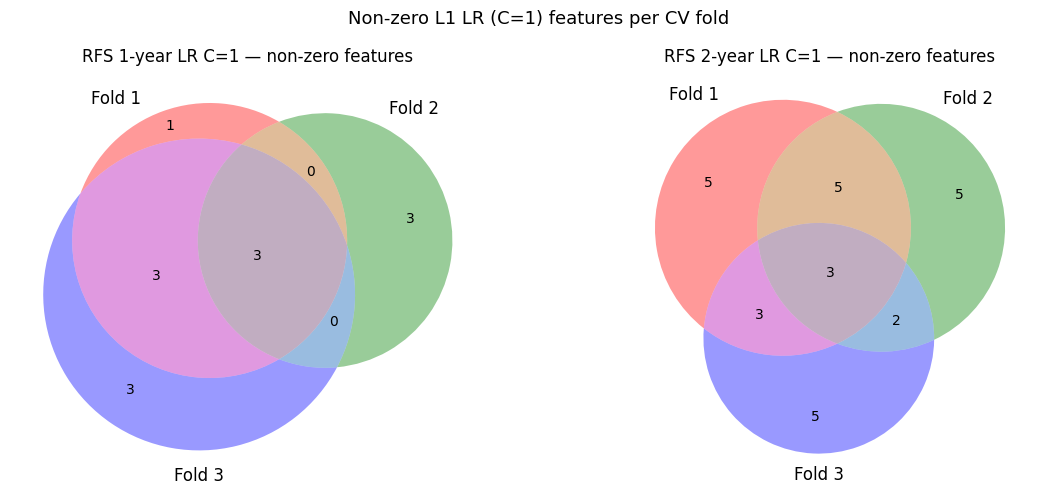

In [13]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (RFS_YEAR, fold_records_lr) in zip(axes, all_fold_records):
    c1_rows = fold_records_lr[
        (fold_records_lr["model"] == "LR_C=1") &
        (fold_records_lr["lr_nonzero_features"].apply(lambda x: x is not None and len(x) > 0))
    ]

    fold_sets = {}
    for _, row in c1_rows.iterrows():
        fold_sets[row["fold"]] = set(row["lr_nonzero_features"]["feature"])

    sets = [fold_sets.get(i, set()) for i in [1, 2, 3]]
    v = venn3(sets, set_labels=("Fold 1", "Fold 2", "Fold 3"), ax=ax)
    ax.set_title(f"RFS {RFS_YEAR}-year LR C=1 — non-zero features", fontsize=12)

    # Print intersections
    f12 = sets[0] & sets[1]
    f13 = sets[0] & sets[2]
    f23 = sets[1] & sets[2]
    f123 = sets[0] & sets[1] & sets[2]
    print(f"\nRFS {RFS_YEAR}y (fold sizes: {[len(s) for s in sets]})")
    print(f"  F1∩F2: {sorted(f12) or 'empty'}")
    print(f"  F1∩F3: {sorted(f13) or 'empty'}")
    print(f"  F2∩F3: {sorted(f23) or 'empty'}")
    print(f"  F1∩F2∩F3: {sorted(f123) or 'empty'}")

plt.suptitle("Non-zero L1 LR (C=1) features per CV fold", fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rfs_lr_c1_venn.png", bbox_inches="tight", dpi=150)
plt.show()